# Iter-8 Integrity-Lock Eval — De-Inflated Lead, Dual Forget Instruments, Retraction

This notebook is a **pure-CPU, $0, read-only re-analysis** over already-collected feature-editing
data from earlier iterations of the *Catching Silent Feature Absorption* project. It is the
demo version of `eval.py`.

It re-examines whether a **single discovered SAE absorber latent** is genuinely a better
unlearning handle than dense (labeled) baselines, by **recomputing every headline number from the
stored per-prompt source columns** and **cross-checking** it against the value the original run
stored. Mismatches would be *reported, never patched* — this is the project's *integrity-lock*
pattern.

**Inputs** (bundled into one `mini_demo_data.json`):

| tag | source | used for |
|-----|--------|----------|
| `D1` | iter-7 exp1 (gated-dense control) | per-prompt joint utilities, per-case operating points |
| `D2` | iter-7 exp2 (named-entity homograph) | Amazon/Bush supporting cases, gate calibration |
| `D3` | iter-6 exp1 (`u_sub` baseline) | Georgia +0.561 retraction source |

**What it computes (Groups A–E):**
- **A — De-inflation.** The honest lead is *KG-ABL vs the strongest **un**gated dense* = **+1.00**
  on `large`; the louder +1.58 gap is only a robustness check against a β≈3 over-erased gated dense.
- **B — Both forget instruments side-by-side.** Gold-completion-drop and a frozen sub-probe-drop
  **disagree in sign** at the KL-matched point ⇒ KL-matching ≠ behavioral matching.
- **C — Concentration vs absorption predictor.** The edit-win predictor is latent **concentration**
  (precision × single-latent leverage, r≈+0.63), **not** the absorption-regime label (r≈−0.09).
- **D — Georgia +0.561 retraction.** That iter-6 "win" sat at a **near-NOOP** operating point.
- **E — Operator-divergence flag.** D1 and D2 calibrate their gates on *different* footprints.

The headline result is `44/44` recompute-vs-stored cross-checks **pass**.

## Setup — install dependencies

`eval.py` only needs `numpy`, `scipy`, and `loguru`. On Colab `numpy`/`scipy`/`matplotlib` are
pre-installed (do **not** reinstall them there — it corrupts the loaded C-extensions); locally we
pin them to Colab's exact versions so the environment matches.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy / scipy / matplotlib — pre-installed on Colab; install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports & logging

The import block is copied verbatim from `eval.py` (plus `matplotlib` for the final
visualization). The loguru logger is configured exactly as in the script, except `HERE` is the
current working directory instead of the script's folder.

In [2]:
from __future__ import annotations
from loguru import logger
from pathlib import Path
import json
import sys
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- logging setup (verbatim from eval.py; HERE = cwd in the notebook) ---
HERE = Path.cwd()
(HERE / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(HERE / "logs/run.log"), rotation="30 MB", level="DEBUG")

2

## Data loading

`eval.py` reads three dependency files from `deps/`. For the demo they are bundled into one
`mini_demo_data.json` (`{"D1": ..., "D2": ..., "D3": ...}`). Each entry keeps its full `metadata`
block and the single per-prompt dataset the script actually reads, with per-prompt rows trimmed to
only the columns the recompute touches — so every cross-check stays bit-for-bit exact.

The loader tries the GitHub raw URL first, then falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-8/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Top-level keys:", list(data.keys()))
for k in data:
    md_ = data[k]["metadata"]
    pp = [(x["dataset"], len(x["examples"])) for x in data[k]["datasets"]]
    print(f"  {k}: {md_.get('method_name', '?')}  per-prompt={pp}")

Top-level keys: ['D1', 'D2', 'D3']
  D1: M1'' KG-Localized Single-Absorber Suppression vs FOOTPRINT-MATCHED Gated-Dense Control  per-prompt=[('gated_dense_per_prompt', 288)]
  D2: M2'' Named-Entity Homograph Absorption Screen + Conditional Gated-Dense Downstream  per-prompt=[]
  D3: M1' KG-Localized Single-Absorber Unlearning vs SUB-CONTEXT-Targeted Dense Erasure  per-prompt=[('unlearn_per_prompt', 226)]


## Config — tunable parameters

All knobs live here. `B_BOOT` is the bootstrap-resample count and is the only meaningful runtime
lever (Group C bootstraps a correlation per resample). The original `eval.py` used
`B_BOOT = 10000`; the full value runs in ~25 s, so the demo can use it directly. Point estimates
are deterministic in `B_BOOT`; only the CI widths depend on it.

In [5]:
SEED   = 1234       # RNG seed (deterministic bootstrap)
B_BOOT = 10000      # bootstrap resamples (= original eval.py value; runs in ~25 s)
# B_BOOT = 2000     # <- faster demo value; point estimates are identical, only CI widths differ
TOL    = 1e-3       # point-stat match tolerance for cross-checks
PRES   = ("RETAIN", "UNRELATED")   # preservation roles (faithful to method.py PRES)

# operator name maps (dataset utility key suffix -> stored operator name)
OP_NAME = {"kg": "KG-ABL", "gated": "DENSE-SUB-ABL-GATED", "sub": "DENSE-SUB-ABL",
           "whole": "DENSE-WHOLE-ABL"}

## Faithful primitives

These are copied verbatim from `eval.py`: the per-prompt joint-utility harmonic mean (the same
`HM(fluency, content_pres)` the original judging used), the paired bootstrap for a difference of
means, CI-overlap, a bootstrap CI for a correlation, and a JSON-safe float coercer. Their `B`
defaults bind to the `B_BOOT` set in the config cell above.

In [6]:
# --------------------------------------------------------------------------- faithful primitives
def harmonic_mean(f, c):
    """Joint per-prompt utility = HM(fluency, content_pres). Verbatim from method.py."""
    f = float(f); c = float(c)
    if f <= 0 and c <= 0:
        return 0.0
    return (2.0 * f * c) / (f + c + 1e-9)


def paired_bootstrap_diff(a, b, rng, B=B_BOOT):
    """Verbatim reproduction of core.paired_bootstrap_diff (a - b, paired resample)."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0}
    idx = rng.integers(0, n, size=(B, n))
    d = a[idx].mean(1) - b[idx].mean(1)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"diff": float(a.mean() - b.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n)}


def ci_overlap(a, b):
    """True if two CI intervals [lo,hi] overlap."""
    if a is None or b is None:
        return False
    return not (a["ci_hi"] < b["ci_lo"] or b["ci_hi"] < a["ci_lo"])


def bootstrap_corr_ci(x, y, kind, rng, B=B_BOOT):
    """Bootstrap CI for a correlation, resampling CASES (paired). kind in {pearson,spearman}.
    Returns point estimate + percentile CI over resamples with non-degenerate variance."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    if kind == "pearson":
        r0 = float(stats.pearsonr(x, y)[0]) if (x.std() > 0 and y.std() > 0) else float("nan")
    else:
        r0 = float(stats.spearmanr(x, y)[0]) if (x.std() > 0 and y.std() > 0) else float("nan")
    boots = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        if xb.std() == 0 or yb.std() == 0:
            continue
        if kind == "pearson":
            rb = stats.pearsonr(xb, yb)[0]
        else:
            rb = stats.spearmanr(xb, yb)[0]
        if np.isfinite(rb):
            boots.append(rb)
    if boots:
        lo, hi = np.percentile(boots, [2.5, 97.5])
    else:
        lo = hi = float("nan")
    return {"r": r0, "ci_lo": float(lo), "ci_hi": float(hi), "n": int(n),
            "n_valid_boot": int(len(boots)),
            "excl_0": bool(np.isfinite(lo) and np.isfinite(hi) and (lo > 0 or hi < 0))}


def safe_num(v, default=0.0):
    """Coerce to a JSON-safe finite float (metrics_agg must be numbers, no NaN/Inf)."""
    try:
        f = float(v)
    except (TypeError, ValueError):
        return default
    if not math.isfinite(f):
        return default
    return f

## Cross-check ledger

`CrossChecks` records each *recomputed-vs-stored* comparison: scalar points are matched within
`TOL`; bootstrap CIs are matched by point-estimate (within `TOL`) **and** interval overlap (the
original run's global RNG state differed, so CIs are re-seeded and compared by overlap, never
overwritten).

In [7]:
# --------------------------------------------------------------------------- cross-check ledger
class CrossChecks:
    def __init__(self):
        self.rows = []

    def point(self, name, computed, stored, note="", tol=TOL):
        c = None if computed is None else float(computed)
        s = None if stored is None else float(stored)
        if c is None or s is None:
            match = False
            ad = rd = None
        else:
            ad = abs(c - s)
            rd = ad / (abs(s) + 1e-12)
            match = ad <= tol
        self.rows.append({"name": name, "kind": "point", "computed": c, "stored": s,
                          "abs_diff": ad, "rel_diff": rd, "match": bool(match), "note": note})
        logger.info(f"XCHECK[point] {name}: computed={c} stored={s} match={match} {note}")
        return match

    def ci(self, name, computed_ci, stored_ci, note=""):
        """Diff point-estimate checked at TOL; CI checked by overlap."""
        cd = computed_ci["diff"] if computed_ci else None
        sd = stored_ci["diff"] if stored_ci else None
        diff_ok = (cd is not None and sd is not None and abs(cd - sd) <= TOL)
        overlap = ci_overlap(computed_ci, stored_ci)
        match = bool(diff_ok and overlap)
        self.rows.append({
            "name": name, "kind": "ci",
            "computed": computed_ci, "stored": stored_ci,
            "abs_diff": (abs(cd - sd) if (cd is not None and sd is not None) else None),
            "rel_diff": None, "match": match,
            "diff_match": bool(diff_ok), "ci_overlap": bool(overlap), "note": note})
        logger.info(f"XCHECK[ci] {name}: diff {cd} vs {sd} diff_ok={diff_ok} overlap={overlap} {note}")
        return match

## Per-prompt helper

`build_paired` reconstructs the paired per-prompt joint-utility arrays for two operators over the
preservation roles, in dataset order — the input to the paired bootstrap.

In [8]:
# --------------------------------------------------------------------------- per-prompt helpers
def build_paired(rows, case, ka, kb):
    """Paired per-prompt joint-utility arrays for two operators over PRES roles, dataset order.
    Reconstructs _paired_util(judged, gen, opA, opB) from the stored per-prompt utilities."""
    a, b = [], []
    for r in rows:
        if r.get("metadata_case") != case or r.get("metadata_role") not in PRES:
            continue
        ua, ub = r.get(f"metadata_utility_{ka}"), r.get(f"metadata_utility_{kb}")
        if ua is None or ub is None:
            continue
        a.append(float(ua)); b.append(float(ub))
    return np.array(a), np.array(b)

## Group A — De-inflation of the lead

Recompute each operator's mean joint utility from the per-prompt rows, then the paired-bootstrap
diffs. The **de-inflated** lead is *KG-ABL − strongest ungated dense (`DENSE-SUB-ABL`)*; the
**inflated** gap is *KG-ABL − the footprint-gated dense*, which the calibration drove to heavy
over-erasure. `group_a_d2` adds the D2 (Amazon/Bush) supporting rows, which use a different gate
operator and are *not* pooled into the D1 lead.

In [9]:
# =========================================================================== GROUP A
def group_a(d1, rows, xc, rng):
    logger.info("===== GROUP A: DE-INFLATION =====")
    per_case = d1["metadata"]["per_case"]
    a_rows = []
    metrics = {}
    for pc in per_case:
        case = pc["case_id"]
        sub = pc["target_subcontext"]
        # A1: recompute joint means from per-prompt utilities
        uK_g, uG_g = build_paired(rows, case, "kg", "gated")     # KG vs GATED paired set
        uK_s, uS_s = build_paired(rows, case, "kg", "sub")        # KG vs SUB paired set
        kg_mean = float(uK_g.mean()) if len(uK_g) else None
        gated_mean = float(uG_g.mean()) if len(uG_g) else None
        sub_mean = float(uS_s.mean()) if len(uS_s) else None
        xc.point(f"A1.kg_joint_mean[{case}]", kg_mean, pc.get("kg_joint_utility_mean"))
        xc.point(f"A1.gated_joint_mean[{case}]", gated_mean, pc.get("gated_joint_utility_mean"))
        xc.point(f"A1.sub_joint_mean[{case}]", sub_mean, pc.get("sub_joint_utility_mean"))

        # A2: paired bootstrap diffs (recompute, seed 1234)
        inflated = paired_bootstrap_diff(uK_g, uG_g, rng)         # KG - GATED (inflated lead)
        lead = paired_bootstrap_diff(uK_s, uS_s, rng)             # KG - SUB   (de-inflated lead)
        xc.ci(f"A2.inflated_KG_vs_GATED[{case}]", inflated, pc.get("joint_diff_CI_KG_vs_GATED"),
              note="recompute seed=1234; CI by overlap (orig rng-state differs)")
        xc.ci(f"A2.deinflated_KG_vs_SUB[{case}]", lead, pc.get("joint_diff_CI_KG_vs_SUB_secondary"),
              note="recompute seed=1234; CI by overlap")

        # A2 reconciliation: kg - sub == lead.diff ; kg - gated == inflated.diff
        if kg_mean is not None and sub_mean is not None:
            xc.point(f"A2.reconcile_lead[{case}]", kg_mean - sub_mean, lead["diff"],
                     note="kg_mean - sub_mean == lead diff")
        if kg_mean is not None and gated_mean is not None:
            xc.point(f"A2.reconcile_inflated[{case}]", kg_mean - gated_mean, inflated["diff"],
                     note="kg_mean - gated_mean == inflated diff")

        # A3: over-erasure stats
        g_col = pc.get("retain_collateral_kl_gated_mean")
        s_col = pc.get("retain_collateral_kl_sub_mean")
        k_col = pc.get("retain_collateral_kl_kg_mean")
        over_ratio = (g_col / s_col) if (g_col and s_col) else None
        gvu = pc.get("gated_vs_ungated_collateral_CI") or {}
        row = {
            "case_id": case, "target_subcontext": sub, "regime": pc["regime"],
            "kg_joint_mean": kg_mean, "gated_joint_mean": gated_mean, "sub_joint_mean": sub_mean,
            "lead_diff_KG_vs_SUB": lead["diff"], "lead_ci_lo": lead["ci_lo"], "lead_ci_hi": lead["ci_hi"],
            "lead_excl_0": lead["excl_0"], "n_lead": lead["n"],
            "inflated_diff_KG_vs_GATED": inflated["diff"], "inflated_ci_lo": inflated["ci_lo"],
            "inflated_ci_hi": inflated["ci_hi"], "inflated_excl_0": inflated["excl_0"], "n_inflated": inflated["n"],
            "kg_collateral": k_col, "gated_collateral": g_col, "sub_collateral": s_col,
            "over_erasure_ratio_gated_over_sub": over_ratio,
            "scale_gated_beta": pc.get("scale_gated_beta"), "scale_sub_beta": pc.get("scale_sub_beta"),
            "gated_vs_ungated_collateral_diff": gvu.get("diff"),
            "gated_vs_ungated_collateral_excl_0": bool(gvu.get("excl_0")),
            "collateral_diff_CI_KG_vs_GATED": (pc.get("collateral_diff_CI_KG_vs_GATED") or {}).get("diff"),
            "collateral_diff_CI_KG_vs_SUB": (pc.get("collateral_diff_CI_KG_vs_SUB_secondary") or {}).get("diff"),
            "source": "D1_iter7_exp1", "gate_operator": "global_footprint_match",
        }
        a_rows.append(row)
        if case == "first_letter_large":
            metrics["de_inflated_lead_large"] = lead["diff"]
            metrics["de_inflated_lead_large_ci_lo"] = lead["ci_lo"]
            metrics["de_inflated_lead_large_ci_hi"] = lead["ci_hi"]
            metrics["inflated_gap_large"] = inflated["diff"]
            metrics["inflated_gap_large_ci_lo"] = inflated["ci_lo"]
            metrics["inflated_gap_large_ci_hi"] = inflated["ci_hi"]
            metrics["over_erasure_ratio_large"] = over_ratio
            metrics["scale_gated_beta_large"] = pc.get("scale_gated_beta")
            metrics["scale_sub_beta_large"] = pc.get("scale_sub_beta")
            metrics["large_collateral_gated"] = g_col
            metrics["large_collateral_sub"] = s_col
    return a_rows, metrics


def group_a_d2(d2):
    """D2 Amazon/Bush de-inflation supporting rows (95%-X-rate gate; NOT pooled into D1 lead)."""
    out = []
    for dc in d2["metadata"]["downstream"]:
        if dc["case_id"] not in ("named_entity_amazon", "named_entity_bush"):
            continue
        col = dc.get("retain_collateral_kl_means", {})
        g_col = col.get("DENSE-SUB-ABL-GATED"); s_col = col.get("DENSE-SUB-ABL"); k_col = col.get("KG-ABL")
        jg = dc.get("joint_diff_CI_KG_vs_GATED") or {}
        js = dc.get("joint_diff_CI_KG_vs_SUB") or {}
        out.append({
            "case_id": dc["case_id"], "target_subcontext": dc["target_subcontext"], "regime": dc["regime"],
            "kg_joint_mean": dc.get("kg_joint_utility_mean"), "gated_joint_mean": dc.get("gated_joint_utility_mean"),
            "sub_joint_mean": dc.get("sub_joint_utility_mean"),
            "lead_diff_KG_vs_SUB": js.get("diff"), "lead_ci_lo": js.get("ci_lo"), "lead_ci_hi": js.get("ci_hi"),
            "lead_excl_0": bool(js.get("excl_0")), "n_lead": js.get("n"),
            "inflated_diff_KG_vs_GATED": jg.get("diff"), "inflated_ci_lo": jg.get("ci_lo"),
            "inflated_ci_hi": jg.get("ci_hi"), "inflated_excl_0": bool(jg.get("excl_0")), "n_inflated": jg.get("n"),
            "kg_collateral": k_col, "gated_collateral": g_col, "sub_collateral": s_col,
            "over_erasure_ratio_gated_over_sub": (g_col / s_col) if (g_col and s_col) else None,
            "scale_gated_beta": dc.get("scale_gated_beta"), "scale_sub_beta": dc.get("scale_sub_beta"),
            "gated_vs_ungated_collateral_diff": None, "gated_vs_ungated_collateral_excl_0": None,
            "collateral_diff_CI_KG_vs_GATED": None, "collateral_diff_CI_KG_vs_SUB": None,
            "source": "D2_iter7_exp2", "gate_operator": "Xpositive_rate_clamped_0.95",
        })
    return out

## Group B — Both meaningful-forget instruments side-by-side

For each (case, operator) lay the **gold-completion-drop** next to the **frozen sub-probe-drop** at
the next-token-KL-matched point. On `large` the two instruments **disagree in sign** for the
KG-vs-gated contrast — and it is the only *material* flip (both instruments move substantially);
the other raw flips are on near-zero magnitudes.

In [10]:
# =========================================================================== GROUP B
def group_b(d1, xc):
    logger.info("===== GROUP B: BOTH FORGET INSTRUMENTS =====")
    per_case = d1["metadata"]["per_case"]
    rows = []
    disagreement_cases = []
    material_disagreement_cases = []
    case_summ = {}
    metrics = {}
    MATERIAL_MAG = 0.05  # min |contrast| on BOTH instruments to count as a material (non-noise) flip
    OPS = [("KG", "KG-ABL"), ("GATED", "DENSE-SUB-ABL-GATED"), ("SUB", "DENSE-SUB-ABL")]
    for pc in per_case:
        case = pc["case_id"]
        cdm = pc.get("completion_drop_matched", {})
        spd = pc.get("subprobe_drop", {})
        noop_pos = (spd.get("NOOP") or {}).get("pos_rate")
        auc = spd.get("auc")
        comp = {}; sub = {}; comp_n = {}; comp_excl = {}
        for short, opname in OPS:
            o = cdm.get(opname, {}) or {}
            dci = o.get("drop_ci") or {}
            comp[short] = o.get("drop_vs_noop")
            comp_n[short] = dci.get("n")
            comp_excl[short] = bool(dci.get("excl_0"))
            sub[short] = (spd.get(opname) or {}).get("drop")
            rows.append({
                "case_id": case, "target_subcontext": pc["target_subcontext"], "regime": pc["regime"],
                "operator": short, "operator_full": opname,
                "completion_drop_vs_noop": comp[short], "completion_drop_ci_excl_0": comp_excl[short],
                "completion_drop_ci_n": comp_n[short],
                "subprobe_drop": sub[short], "subprobe_noop_pos_rate": noop_pos, "subprobe_auc": auc,
            })
        # B2 instrument disagreement on the decisive KG-vs-GATED contrast
        comp_contrast = (comp["KG"] - comp["GATED"]) if (comp["KG"] is not None and comp["GATED"] is not None) else None
        sub_contrast = (sub["KG"] - sub["GATED"]) if (sub["KG"] is not None and sub["GATED"] is not None) else None
        sign_div = bool(comp_contrast is not None and sub_contrast is not None
                        and np.sign(comp_contrast) != np.sign(sub_contrast)
                        and comp_contrast != 0 and sub_contrast != 0)
        # rank disagreement: Kendall tau between the two instruments over {KG,GATED,SUB}
        cvals = [comp[s] for s, _ in OPS]
        svals = [sub[s] for s, _ in OPS]
        if all(v is not None for v in cvals + svals) and len(set(cvals)) > 1 and len(set(svals)) > 1:
            tau = float(stats.kendalltau(cvals, svals)[0])
            rho = float(stats.spearmanr(cvals, svals)[0])
        else:
            tau = rho = None
        # B3 across-operator spread at the KL-matched point
        comp_valid = [v for v in cvals if v is not None]
        sub_valid = [v for v in svals if v is not None]
        comp_spread = (max(comp_valid) - min(comp_valid)) if comp_valid else None
        sub_spread = (max(sub_valid) - min(sub_valid)) if sub_valid else None
        material = bool(sign_div and comp_contrast is not None and sub_contrast is not None
                        and abs(comp_contrast) >= MATERIAL_MAG and abs(sub_contrast) >= MATERIAL_MAG)
        if sign_div:
            disagreement_cases.append(case)
        if material:
            material_disagreement_cases.append(case)
        case_summ[case] = {
            "completion_contrast_KG_minus_GATED": comp_contrast,
            "subprobe_contrast_KG_minus_GATED": sub_contrast,
            "sign_divergence": sign_div,
            "material_sign_divergence": material,
            "kendall_tau_instruments": tau, "spearman_instruments": rho,
            "completion_spread_at_matched": comp_spread, "subprobe_spread_at_matched": sub_spread,
            "completion_ci_n_kg": comp_n["KG"], "completion_ci_n_gated": comp_n["GATED"],
            "kg_can_forget": pc.get("kg_can_forget"),
        }
        # cross-check the load-bearing large contrasts against the stored drops
        if case == "first_letter_large":
            xc.point("B2.large_completion_drop_KG", comp["KG"],
                     (cdm.get("KG-ABL") or {}).get("drop_vs_noop"))
            xc.point("B2.large_completion_drop_GATED", comp["GATED"],
                     (cdm.get("DENSE-SUB-ABL-GATED") or {}).get("drop_vs_noop"))
            xc.point("B2.large_subprobe_drop_KG", sub["KG"],
                     (spd.get("KG-ABL") or {}).get("drop"))
            xc.point("B2.large_subprobe_drop_GATED", sub["GATED"],
                     (spd.get("DENSE-SUB-ABL-GATED") or {}).get("drop"))
            metrics["large_kg_vs_gated_completion_contrast"] = comp_contrast
            metrics["large_kg_vs_gated_subprobe_contrast"] = sub_contrast
            metrics["large_completion_spread_at_matched"] = comp_spread
            metrics["large_subprobe_spread_at_matched"] = sub_spread
            metrics["large_completion_ci_n"] = comp_n["KG"]
            metrics["large_instrument_sign_divergence"] = 1.0 if sign_div else 0.0
    metrics["n_instrument_disagreement_cases"] = float(len(disagreement_cases))
    metrics["n_material_instrument_disagreement_cases"] = float(len(material_disagreement_cases))
    return rows, case_summ, disagreement_cases, material_disagreement_cases, metrics

## Group C — Concentration vs absorption as the win predictor

Build per-case concentration proxies and correlate them with the edit-win. The headline proxy is
**v2 = precision × single-latent leverage** (`max_forget_kg`); it tracks the win where the
absorption-regime label does not, and the inverse-footprint proxy **v1** *anti*-correlates because
distributed senses also fire sparsely. Descriptive and small-n (pooled n=7).

In [11]:
# =========================================================================== GROUP C
def group_c(d1, d2, xc, rng):
    logger.info("===== GROUP C: CONCENTRATION vs ABSORPTION PREDICTOR =====")
    cases = []
    # --- D1 cases (5): footprint = absorber's own token footprint (forget_kg_footprints) ---
    for pc in d1["metadata"]["per_case"]:
        fk = [v for v in pc.get("forget_kg_footprints", []) if v and v > 0]
        f_kg = fk[0] if fk else pc.get("gate_target_footprint")
        spd = pc.get("subprobe_drop", {})
        sub_drops = [(spd.get(op) or {}).get("drop") for op in
                     ("KG-ABL", "DENSE-SUB-ABL-GATED", "DENSE-SUB-ABL")]
        sub_drops = [d for d in sub_drops if d is not None]
        sub_probe_max_drop = max(sub_drops) if sub_drops else None
        fork = pc["fork_verdict"]
        cases.append({
            "case_id": pc["case_id"], "target_subcontext": pc["target_subcontext"],
            "source": "D1", "regime": pc["regime"],
            "absorber_precision": pc["absorber_precision"], "f_kg": f_kg,
            "firing_jaccard_with_parent": pc["firing_jaccard_with_parent"],
            "max_forget_kg": pc["max_forget_kg"], "parent_recall_hole": pc.get("parent_recall_hole"),
            "sub_probe_max_drop": sub_probe_max_drop,
            "win_binary": 1.0 if fork == "KG_BEATS_GATED_DENSE_AT_MEANINGFUL_FORGET" else 0.0,
            "meaningful_forget_binary": 1.0 if pc.get("kg_can_forget") else 0.0,
            "adv_continuous": (pc.get("joint_diff_CI_KG_vs_GATED") or {}).get("diff"),
            "fork_verdict": fork,
        })
    # --- D2 cases (Amazon, Bush only; Georgia is a duplicate control -> excluded) ---
    screen = {r["entity"]: r for r in d2["metadata"]["screen_table"]}
    name2ent = {"named_entity_amazon": "Amazon", "named_entity_bush": "Bush"}
    for dc in d2["metadata"]["downstream"]:
        if dc["case_id"] not in name2ent:
            continue
        ent = name2ent[dc["case_id"]]
        fk = [v for v in dc.get("forget_kg_footprints", []) if v and v > 0]
        f_kg = fk[0] if fk else None
        prec = screen.get(ent, {}).get("precision", dc.get("absorber_precision"))
        evn = dc.get("edit_vs_noop_forget", {})
        fork = dc["fork_verdict"]
        cases.append({
            "case_id": dc["case_id"], "target_subcontext": dc["target_subcontext"],
            "source": "D2", "regime": dc["regime"],
            "absorber_precision": prec, "f_kg": f_kg,
            "firing_jaccard_with_parent": dc.get("firing_jaccard_with_parent"),
            "max_forget_kg": dc.get("max_forget_kg"), "parent_recall_hole": dc.get("parent_recall_hole"),
            "sub_probe_max_drop": None,  # D2 has no frozen sub-probe instrument
            "win_binary": 1.0 if fork == "KG_BEATS_GATED_DENSE" else 0.0,
            "meaningful_forget_binary": 1.0 if evn.get("nontrivial_forget") else 0.0,
            "adv_continuous": (dc.get("joint_diff_CI_KG_vs_GATED") or {}).get("diff"),
            "fork_verdict": fork,
        })

    # --- concentration proxies ---
    for c in cases:
        prec = c["absorber_precision"]; f_kg = c["f_kg"]
        c["concentration_v1_prec_over_footprint"] = (prec / f_kg) if (prec is not None and f_kg) else None
        c["concentration_v2_prec_x_leverage"] = (prec * c["max_forget_kg"]) \
            if (prec is not None and c["max_forget_kg"] is not None) else None
        if (prec is not None and c["firing_jaccard_with_parent"] is not None
                and c["sub_probe_max_drop"] is not None):
            c["concentration_v3_prec_x_disjoint_x_subdrop"] = \
                prec * (1.0 - c["firing_jaccard_with_parent"]) * c["sub_probe_max_drop"]
        else:
            c["concentration_v3_prec_x_disjoint_x_subdrop"] = None
        c["absorption_label_binary"] = 1.0 if c["regime"] == "absorption" else 0.0

    # z-scores (for ranking transparency) on the pooled 7-case set per proxy
    for proxy in ("concentration_v1_prec_over_footprint", "concentration_v2_prec_x_leverage"):
        vals = np.array([c[proxy] for c in cases], float)
        mu, sd = np.nanmean(vals), np.nanstd(vals)
        for c in cases:
            c[proxy + "_z"] = float((c[proxy] - mu) / sd) if (sd > 0 and c[proxy] is not None) else None

    # --- predictive comparison ---
    def corr_table(case_subset, proxy_key, outcome_key, kind, label):
        xs, ys = [], []
        for c in case_subset:
            if c.get(proxy_key) is None or c.get(outcome_key) is None:
                continue
            xs.append(c[proxy_key]); ys.append(c[outcome_key])
        if len(xs) < 3 or len(set(ys)) < 2 or len(set(xs)) < 2:
            return None
        res = bootstrap_corr_ci(xs, ys, kind, rng)
        res["label"] = label; res["proxy"] = proxy_key; res["outcome"] = outcome_key
        res["n_cases"] = len(xs)
        return res

    pooled = cases  # 7 cases
    d1_only = [c for c in cases if c["source"] == "D1"]  # 5 cases (robustness, single gate operator)

    proxies = ["concentration_v1_prec_over_footprint", "concentration_v2_prec_x_leverage",
               "concentration_v3_prec_x_disjoint_x_subdrop", "absorption_label_binary"]
    corr_results = {"pooled_win_pointbiserial": {}, "pooled_meaningful_pointbiserial": {},
                    "pooled_adv_spearman": {}, "d1_win_pointbiserial": {}}
    for p in proxies:
        corr_results["pooled_win_pointbiserial"][p] = corr_table(pooled, p, "win_binary", "pearson", f"{p} vs win (pooled n7)")
        corr_results["pooled_meaningful_pointbiserial"][p] = corr_table(pooled, p, "meaningful_forget_binary", "pearson", f"{p} vs meaningful (pooled n7)")
        corr_results["pooled_adv_spearman"][p] = corr_table(pooled, p, "adv_continuous", "spearman", f"{p} vs adv (pooled n7)")
        corr_results["d1_win_pointbiserial"][p] = corr_table(d1_only, p, "win_binary", "pearson", f"{p} vs win (D1 n5)")

    def r_of(block, p):
        b = corr_results[block].get(p)
        return b["r"] if b else None

    # primary headline proxy: v2 (precision x single-latent leverage) -- the proxy the plan's
    # qualitative examples actually invoke (Amazon max_kg 1.14, large 0.45). v1 (inverse global
    # footprint) ANTI-correlates because distributed senses (Georgia/Jordan) also fire sparsely.
    abs_r_win = r_of("pooled_win_pointbiserial", "absorption_label_binary")
    v1_r_win = r_of("pooled_win_pointbiserial", "concentration_v1_prec_over_footprint")
    v2_r_win = r_of("pooled_win_pointbiserial", "concentration_v2_prec_x_leverage")
    v3_r_win_d1 = r_of("d1_win_pointbiserial", "concentration_v3_prec_x_disjoint_x_subdrop")

    predictive_delta_v2 = (v2_r_win - abs_r_win) if (v2_r_win is not None and abs_r_win is not None) else None
    predictive_delta_v1 = (v1_r_win - abs_r_win) if (v1_r_win is not None and abs_r_win is not None) else None
    # bootstrap CI on the v2 delta (paired resample of cases)
    delta_ci = bootstrap_delta_ci(pooled, "concentration_v2_prec_x_leverage",
                                  "absorption_label_binary", "win_binary", rng)

    concentration_outpredicts = bool(
        v2_r_win is not None and abs_r_win is not None and v2_r_win > abs_r_win and v2_r_win > 0)

    # cross-check the thin absorption-vs-cofiring aggregate the paper currently leans on
    summ = d1["metadata"]["summary"]
    xc.point("C3.adv_absorption_mean", summ.get("adv_absorption_mean"), 1.583333332976852,
             note="1-case mean (only first_letter_large is a powered absorption WIN)")
    xc.point("C3.adv_cofiring_mean", summ.get("adv_cofiring_mean"), 0.3724747474090908,
             note="2-case mean (taxonomic_us + toxicity_insult); thin/asymmetric basis")

    metrics = {
        "concentration_vs_absorption_predictive_delta": predictive_delta_v2,
        "concentration_vs_absorption_predictive_delta_ci_lo": (delta_ci or {}).get("ci_lo"),
        "concentration_vs_absorption_predictive_delta_ci_hi": (delta_ci or {}).get("ci_hi"),
        "concentration_vs_absorption_predictive_delta_v1_footprint": predictive_delta_v1,
        "corr_concentration_v1_win": v1_r_win,
        "corr_concentration_v2_win": v2_r_win,
        "corr_concentration_v3_win_d1": v3_r_win_d1,
        "corr_absorption_label_win": abs_r_win,
        "corr_concentration_v2_meaningful": r_of("pooled_meaningful_pointbiserial", "concentration_v2_prec_x_leverage"),
        "corr_absorption_label_meaningful": r_of("pooled_meaningful_pointbiserial", "absorption_label_binary"),
        "spearman_concentration_v2_adv": r_of("pooled_adv_spearman", "concentration_v2_prec_x_leverage"),
        "spearman_absorption_label_adv": r_of("pooled_adv_spearman", "absorption_label_binary"),
        "concentration_outpredicts_absorption": 1.0 if concentration_outpredicts else 0.0,
        "n_concentration_cases": float(len(pooled)),
        "adv_absorption_mean": summ.get("adv_absorption_mean"),
        "adv_cofiring_mean": summ.get("adv_cofiring_mean"),
        "n_absorption_cases_in_mean": 1.0,   # only first_letter_large is a powered absorption win
        "n_cofiring_cases_in_mean": 2.0,     # taxonomic_us + toxicity_insult
    }
    return cases, corr_results, metrics


def bootstrap_delta_ci(cases, proxy_a, proxy_b, outcome, rng, B=B_BOOT):
    """Bootstrap CI for delta = corr(proxy_a, outcome) - corr(proxy_b, outcome), resampling cases."""
    rows = [(c.get(proxy_a), c.get(proxy_b), c.get(outcome)) for c in cases
            if c.get(proxy_a) is not None and c.get(proxy_b) is not None and c.get(outcome) is not None]
    if len(rows) < 3:
        return None
    A = np.array([r[0] for r in rows], float)
    Bv = np.array([r[1] for r in rows], float)
    Y = np.array([r[2] for r in rows], float)
    n = len(rows)

    def _r(x, y):
        if x.std() == 0 or y.std() == 0:
            return np.nan
        return stats.pearsonr(x, y)[0]

    d0 = _r(A, Y) - _r(Bv, Y)
    boots = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        ra = _r(A[idx], Y[idx]); rb = _r(Bv[idx], Y[idx])
        if np.isfinite(ra) and np.isfinite(rb):
            boots.append(ra - rb)
    if not boots:
        return {"delta": float(d0) if np.isfinite(d0) else None, "ci_lo": None, "ci_hi": None, "n": n}
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return {"delta": float(d0), "ci_lo": float(lo), "ci_hi": float(hi), "n": n,
            "n_valid_boot": len(boots), "excl_0": bool(lo > 0 or hi < 0)}

## Group D — Georgia +0.561 retraction

Recompute the iter-6 Georgia KG-vs-dense "win" from D3 (+0.5606), then show it sat at a
**near-NOOP** operating point in iter-7: a tiny single-latent forget-KL ceiling, ~89%
NOOP-identical forget prompts, and a barely-moving frozen sub-probe ⇒ retracted as low-collateral
partial suppression.

In [12]:
# =========================================================================== GROUP D
def group_d(d1, d3, xc, rng):
    logger.info("===== GROUP D: GEORGIA +0.561 RETRACTION =====")
    # D3 iter-6 Georgia KG-vs-SUB joint
    g3 = next(pc for pc in d3["metadata"]["per_case"] if pc.get("case_id") == "taxonomic_georgia")
    stored_ci = g3.get("joint_diff_CI_KG_vs_SUB")
    matched_kl6 = g3.get("matched_target_forget_kl")
    # recompute from D3 unlearn_per_prompt if utility columns present
    d3_rows = next((d["examples"] for d in d3["datasets"] if d["dataset"] == "unlearn_per_prompt"), [])
    uK, uS = build_paired(d3_rows, "taxonomic_georgia", "kg", "sub")
    if len(uK) >= 6:
        recomp = paired_bootstrap_diff(uK, uS, rng)
        xc.ci("D1.georgia_iter6_KG_vs_SUB", recomp, stored_ci,
              note="recompute from D3 unlearn_per_prompt; CI by overlap")
        recomputed_diff = recomp["diff"]
    else:
        xc.point("D1.georgia_iter6_KG_vs_SUB_diff(stored-only)", None, (stored_ci or {}).get("diff"),
                 note="stored-only (recompute unavailable: per-prompt utility columns absent)")
        recomputed_diff = None

    # D1 iter-7 near-NOOP evidence at/near that operating point for Georgia
    g7 = next(pc for pc in d1["metadata"]["per_case"] if pc.get("case_id") == "taxonomic_georgia")
    max_kg7 = g7.get("max_forget_kg")
    noop_ident = (g7.get("noop_identical_fraction") or {}).get("FORGET", {}).get("KG-ABL")
    subdrop = (g7.get("subprobe_drop", {}).get("KG-ABL") or {}).get("drop")
    comp_excl = ((g7.get("completion_drop_matched", {}).get("KG-ABL") or {}).get("drop_ci") or {}).get("excl_0")
    fork7 = g7.get("fork_verdict")
    adv_gated7 = (g7.get("joint_diff_CI_KG_vs_GATED") or {}).get("diff")
    adv_sub7 = (g7.get("joint_diff_CI_KG_vs_SUB_secondary") or {}).get("diff")
    # ceiling ratios: dense vs KG single-latent KL ceiling
    ratio_sub = g7.get("ratio_max_sub_over_kg")
    ratio_gated = g7.get("ratio_max_gated_over_kg")

    retr_row = {
        "case_id": "taxonomic_georgia", "target_subcontext": "Georgia",
        "iter6_adv_KG_vs_SUB": (stored_ci or {}).get("diff"),
        "iter6_adv_ci_lo": (stored_ci or {}).get("ci_lo"), "iter6_adv_ci_hi": (stored_ci or {}).get("ci_hi"),
        "iter6_n": (stored_ci or {}).get("n"),
        "iter6_recomputed_adv_KG_vs_SUB": recomputed_diff,
        "iter6_matched_target_forget_kl": matched_kl6,
        "iter7_max_forget_kg": max_kg7,
        "iter7_ratio_max_sub_over_kg": ratio_sub, "iter7_ratio_max_gated_over_kg": ratio_gated,
        "iter7_noop_identical_forget_kg": noop_ident,
        "iter7_subprobe_drop_kg": subdrop,
        "iter7_completion_drop_ci_excl_0": bool(comp_excl),
        "iter7_fork_verdict": fork7,
        "iter7_adv_KG_vs_GATED": adv_gated7, "iter7_adv_KG_vs_SUB": adv_sub7,
        "retraction_status": "RETRACTED_NEAR_NOOP",
    }
    metrics = {
        "retraction_iter6_georgia_adv": (stored_ci or {}).get("diff"),
        "retraction_iter6_matched_kl": matched_kl6,
        "retraction_iter7_max_forget_kg": max_kg7,
        "retraction_noop_identical": noop_ident,
        "retraction_subprobe_drop": subdrop,
        "retraction_iter7_completion_ci_excl_0": 1.0 if comp_excl else 0.0,
        "retraction_iter7_adv_kg_vs_gated": adv_gated7,
        "retraction_confirmed_near_noop": 1.0,
    }
    return retr_row, metrics

## Group E — Operator-definition divergence

Flag that D1 calibrates its gate on a ~3% **global** token footprint while D2 clamps to a ~95%
**X-positive** firing rate — so the cross-experiment headline aggregates two different gate
operators that iter-8 must unify.

In [13]:
# =========================================================================== GROUP E
def group_e(d1, d2, xc):
    logger.info("===== GROUP E: OPERATOR-DEFINITION DIVERGENCE =====")
    # D1 gate: global-neutral-pool footprint match (calibrate_gate_tau)
    pc_large = next(pc for pc in d1["metadata"]["per_case"] if pc["case_id"] == "first_letter_large")
    pc_geo = next(pc for pc in d1["metadata"]["per_case"] if pc["case_id"] == "taxonomic_georgia")
    d1_taus = [pc.get("gate_tau") for pc in d1["metadata"]["per_case"]]
    d1_footprints = [pc.get("gate_footprint_used") for pc in d1["metadata"]["per_case"]]
    d1_targets = [pc.get("gate_target_footprint") for pc in d1["metadata"]["per_case"]]
    # D2 gate: footprint_match_clamped on X-positive firing rate (~0.95)
    d2_amazon = next(dc for dc in d2["metadata"]["downstream"] if dc["case_id"] == "named_entity_amazon")
    gc = d2_amazon.get("gate_calibration", {})

    rows = [
        {"experiment": "D1_iter7_exp1", "gate_method": "global_neutral_pool_footprint_match (calibrate_gate_tau)",
         "calibrates_on": "global token firing fraction over a neutral pool",
         "gate_tau_range": [min(t for t in d1_taus if t is not None), max(t for t in d1_taus if t is not None)],
         "gate_footprint_used_range": [min(f for f in d1_footprints if f is not None),
                                       max(f for f in d1_footprints if f is not None)],
         "gate_target_footprint_range": [min(f for f in d1_targets if f is not None),
                                         max(f for f in d1_targets if f is not None)],
         "representative_pct_global_firing": pc_large.get("gate_footprint_used"),
         "note": "~1.4-4.5% of ALL tokens edited; large headline (+1.58) is a 3%-global-footprint comparison"},
        {"experiment": "D2_iter7_exp2", "gate_method": gc.get("method"),
         "calibrates_on": "firing rate on X-POSITIVE prompts (clamped)",
         "gate_fire_rate_X": gc.get("gate_fire_rate_X"), "gate_fire_rate_sibling": gc.get("gate_fire_rate_sibling"),
         "rate_used_clamped": gc.get("rate_used_clamped"), "detector_balanced_acc": gc.get("detector_balanced_acc"),
         "note": "~95% of X-positive tokens edited; Amazon win (+0.75) is a 95%-X-rate comparison"},
    ]
    xc.point("E1.D2_gate_fire_rate_X", gc.get("gate_fire_rate_X"), 0.9466666666666667,
             note="D2 gate calibrated on X-positive firing rate, NOT global footprint")
    xc.point("E1.D1_large_gate_footprint_used", pc_large.get("gate_footprint_used"), 0.03,
             note="D1 gate calibrated to ~3% global token footprint")
    metrics = {
        "operator_divergence_flag": 1.0,
        "d1_gate_footprint_used_large": pc_large.get("gate_footprint_used"),
        "d1_gate_target_footprint_georgia": pc_geo.get("gate_target_footprint"),
        "d2_gate_fire_rate_X": gc.get("gate_fire_rate_X"),
        "d2_gate_fire_rate_sibling": gc.get("gate_fire_rate_sibling"),
    }
    return rows, metrics

## Output dataset assembly

Helpers that package every per-case row into the schema-valid `{input, output, predict_*,
metadata_*, eval_*}` example shape for the five output datasets.

In [14]:
# =========================================================================== dataset assembly
def _row(input_s, output_s, predict, metadata, evals=None):
    """Build a schema-valid example: input/output strings, predict_* string, metadata_*, eval_* numbers."""
    r = {"input": str(input_s), "output": str(output_s)}
    if predict is not None:
        r["predict_verdict"] = str(predict)
    for k, v in (metadata or {}).items():
        r[f"metadata_{k}"] = v
    for k, v in (evals or {}).items():
        if v is not None and isinstance(v, (int, float)) and math.isfinite(float(v)):
            r[f"eval_{k}"] = float(v)
    return r


def build_datasets(a_rows, b_rows, c_cases, retr_row, op_rows):
    ds = []

    # 1. de_inflation_per_case
    ex = []
    for r in a_rows:
        ex.append(_row(
            f"De-inflate edit lead for '{r['target_subcontext']}' ({r['regime']}, gate={r['gate_operator']}): "
            f"KG-ABL vs strongest UNGATED dense (DENSE-SUB-ABL) = de-inflated lead; vs footprint-gated dense = inflated.",
            f"lead(KG-SUB)={_f(r['lead_diff_KG_vs_SUB'])} | inflated(KG-GATED)={_f(r['inflated_diff_KG_vs_GATED'])}",
            r["source"],
            {k: r[k] for k in r if k not in ()},
            {"lead_diff_KG_vs_SUB": r["lead_diff_KG_vs_SUB"],
             "inflated_diff_KG_vs_GATED": r["inflated_diff_KG_vs_GATED"],
             "over_erasure_ratio_gated_over_sub": r["over_erasure_ratio_gated_over_sub"]}))
    ds.append({"dataset": "de_inflation_per_case", "examples": ex})

    # 2. both_instrument_per_case_op
    ex = []
    for r in b_rows:
        ex.append(_row(
            f"[{r['target_subcontext']}|{r['operator']}] forget instruments at KL-matched point: "
            f"gold-completion-drop vs frozen sub-probe-drop.",
            f"completion_drop={_f(r['completion_drop_vs_noop'])} (excl0={r['completion_drop_ci_excl_0']}, "
            f"n={r['completion_drop_ci_n']}); subprobe_drop={_f(r['subprobe_drop'])}",
            r["operator"],
            {k: r[k] for k in r},
            {"completion_drop_vs_noop": r["completion_drop_vs_noop"],
             "subprobe_drop": r["subprobe_drop"],
             "completion_drop_ci_excl_0": 1.0 if r["completion_drop_ci_excl_0"] else 0.0}))
    ds.append({"dataset": "both_instrument_per_case_op", "examples": ex})

    # 3. concentration_predictor_per_case
    ex = []
    for c in c_cases:
        ex.append(_row(
            f"Concentration vs absorption predictor for '{c['target_subcontext']}' ({c['source']}, regime={c['regime']}): "
            f"precision={_f(c['absorber_precision'])}, f_kg={_f(c['f_kg'])}, max_forget_kg={_f(c['max_forget_kg'])}. "
            f"Descriptive, small-n (pooled n=7).",
            f"win={int(c['win_binary'])} meaningful_forget={int(c['meaningful_forget_binary'])} "
            f"adv={_f(c['adv_continuous'])} | absorption_label={int(c['absorption_label_binary'])}",
            c["fork_verdict"],
            {k: c[k] for k in c},
            {"win_binary": c["win_binary"], "meaningful_forget_binary": c["meaningful_forget_binary"],
             "absorption_label_binary": c["absorption_label_binary"],
             "concentration_v1_prec_over_footprint": c.get("concentration_v1_prec_over_footprint"),
             "concentration_v2_prec_x_leverage": c.get("concentration_v2_prec_x_leverage"),
             "adv_continuous": c.get("adv_continuous")}))
    ds.append({"dataset": "concentration_predictor_per_case", "examples": ex})

    # 4. retraction_per_case (Georgia primary)
    ex = [_row(
        "Georgia iter-6 +0.561 KG-vs-SUB 'win' RETRACTION: at iter-7 the same operating point is near-NOOP "
        "(tiny single-latent forget KL, ~89% NOOP-identical, frozen sub-probe barely moves).",
        f"iter6_adv=+{_f(retr_row['iter6_adv_KG_vs_SUB'])} -> {retr_row['retraction_status']} "
        f"(iter7 max_forget_kg={_f(retr_row['iter7_max_forget_kg'])}, NOOP-identical={_f(retr_row['iter7_noop_identical_forget_kg'])}, "
        f"subprobe_drop={_f(retr_row['iter7_subprobe_drop_kg'])})",
        retr_row["retraction_status"],
        {k: retr_row[k] for k in retr_row},
        {"iter6_adv_KG_vs_SUB": retr_row["iter6_adv_KG_vs_SUB"],
         "iter7_max_forget_kg": retr_row["iter7_max_forget_kg"],
         "iter7_noop_identical_forget_kg": retr_row["iter7_noop_identical_forget_kg"],
         "iter7_subprobe_drop_kg": retr_row["iter7_subprobe_drop_kg"]})]
    ds.append({"dataset": "retraction_per_case", "examples": ex})

    # 5. operator_divergence
    ex = []
    for r in op_rows:
        evals = {"operator_divergence_flag": 1.0}
        if "representative_pct_global_firing" in r:
            evals["gate_footprint_global"] = r.get("representative_pct_global_firing")
        if "gate_fire_rate_X" in r:
            evals["gate_fire_rate_X"] = r.get("gate_fire_rate_X")
        ex.append(_row(
            f"Operator definition for {r['experiment']}: {r['gate_method']} — calibrates on {r['calibrates_on']}.",
            r["note"],
            r["experiment"],
            {k: (json.dumps(v) if isinstance(v, (list, dict)) else v) for k, v in r.items()},
            evals))
    ds.append({"dataset": "operator_divergence", "examples": ex})
    return ds


def _f(v, nd=4):
    try:
        return round(float(v), nd)
    except (TypeError, ValueError):
        return v

## Paper wording (W1–W5)

Builds the cross-checked drop-in sentences (de-inflated lead, instrument disagreement,
concentration-not-absorption, Georgia retraction, operator unification) for the paper text.

In [15]:
# =========================================================================== paper wording
def build_paper_wording(metrics, disagreement_cases, material_cases, c_metrics):
    lead = metrics.get("de_inflated_lead_large")
    lead_lo = metrics.get("de_inflated_lead_large_ci_lo"); lead_hi = metrics.get("de_inflated_lead_large_ci_hi")
    infl = metrics.get("inflated_gap_large")
    oer = metrics.get("over_erasure_ratio_large")
    cgat = metrics.get("large_collateral_gated"); csub = metrics.get("large_collateral_sub")
    beta = metrics.get("scale_gated_beta_large")
    comp_c = metrics.get("large_kg_vs_gated_completion_contrast")
    sub_c = metrics.get("large_kg_vs_gated_subprobe_contrast")
    v2r = c_metrics.get("corr_concentration_v2_win"); v1r = c_metrics.get("corr_concentration_v1_win")
    absr = c_metrics.get("corr_absorption_label_win")
    return {
        "W1_deinflated_lead":
            f"On the load-bearing first-letter 'large' case the single discovered SAE absorber beats the strongest "
            f"UNGATED dense control (the labeled sub-context diff-of-means) by +{_f(lead,2)} on the joint "
            f"retain-utility x fluency outcome (95% CI [{_f(lead_lo,2)}, {_f(lead_hi,2)}], n=36). The larger "
            f"+{_f(infl,2)} gap is reported only as a robustness check against a footprint-matched gated dense that "
            f"the calibration drove to beta~{_f(beta,1)} over-erasure: its retain collateral ({_f(cgat,3)}) is "
            f"{_f(oer,1)}x its own ungated form ({_f(csub,3)}), so it is a handicapped comparator, not the headline.",
        "W2_instrument_disagreement":
            f"All operators are scaled to the SAME next-token-KL on held-out forget windows, yet at that matched "
            f"point the two meaningful-forget instruments disagree in SIGN for 'large' (the only case with a "
            f"MATERIAL flip — both instruments move substantially): gold-completion-drop favors "
            f"the gated dense (KG minus GATED = {_f(comp_c,2)}, i.e. the gated dense reduces gold-token probability "
            f"more) while the frozen 1-D sub-probe favors KG ({_f(sub_c,2)}). KL-matching therefore does NOT "
            f"equalize behavioral forgetting; operators should be matched on a behavioral measure (sub-probe drop or "
            f"completion accuracy), not next-token KL. The 'large' completion CI is over only n=4 hand probes (a "
            f"rigor caveat we state explicitly).",
        "W3_concentration_not_absorption":
            f"The edit-win predictor is latent CONCENTRATION (precision x single-latent leverage), not the "
            f"absorption-regime label. Wins span an absorption case (large) and a co-firing case (insult); losses "
            f"are distributed senses (Georgia/Jordan country sense, US co-firing) and a low-leverage homograph "
            f"(Bush) -- crossing both regime labels. Across the pooled 7 cases a precision x max-single-latent-KL "
            f"proxy tracks the win (point-biserial r={_f(v2r,2)}) where the absorption label does not "
            f"(r={_f(absr,2)}). Note the inverse-FOOTPRINT proxy fails (r={_f(v1r,2)}): distributed senses also "
            f"fire sparsely, so footprint sparsity alone is not concentration -- single-latent LEVERAGE is. This is "
            f"descriptive and small-n (n=7, two gate operators pooled).",
        "W4_georgia_retraction":
            f"The iter-6 Georgia +{_f(metrics.get('retraction_iter6_georgia_adv'),3)} KG-vs-dense 'win' sat at a "
            f"near-NOOP operating point: the single-latent forget-KL ceiling is only "
            f"{_f(metrics.get('retraction_iter7_max_forget_kg'),3)} (17-30x below the dense ceilings), the edit is "
            f"NOOP-identical on {_f(100*metrics.get('retraction_noop_identical'),0)}% of forget prompts, and the "
            f"frozen sub-probe drops only {_f(metrics.get('retraction_subprobe_drop'),3)}. We retract it as "
            f"low-collateral PARTIAL suppression (KG won by barely editing), not meaningful unlearning.",
        "W5_operator_unification":
            f"Two 'footprint-matched gated dense' controls differ: the iter-7 main experiment matches a ~3% GLOBAL "
            f"token footprint (gate_tau on a neutral pool) while the named-entity experiment clamps the gate to a "
            f"~95% X-POSITIVE firing rate. The current cross-experiment headline therefore aggregates a "
            f"3%-global-footprint comparison (large) with a 95%-X-rate comparison (Amazon); the new iter-8 "
            f"experiments must unify into ONE gate operator or document the per-case clamp in-table.",
        "note_absorption_vs_cofiring_basis":
            f"The reported absorption_exceeds_cofiring aggregate (adv_absorption_mean={_f(metrics.get('adv_absorption_mean'),3)} "
            f"vs adv_cofiring_mean={_f(metrics.get('adv_cofiring_mean'),3)}) rests on a 1-case-vs-2-case mean "
            f"(only first_letter_large is a powered absorption win; US+insult form the co-firing mean). It is "
            f"thin/asymmetric; the per-case concentration correlation supersedes it.",
        "instrument_disagreement_cases_all": disagreement_cases,
        "instrument_disagreement_cases_material": material_cases,
        "note_instrument_materiality":
            "3 cases show a raw sign-flip but 2 (Georgia, insult) flip on near-zero completion-drop "
            "magnitudes (|contrast|<0.05, i.e. neither KG nor the gated dense materially moves gold-token "
            "probability); only 'large' shows a MATERIAL flip with both instruments moving substantially "
            "(completion 1.01, sub-probe 0.42). Cite the material case.",
    }

## Run all groups & assemble `eval_out.json`

This is `main()` from `eval.py`, with the only change being that `d1`/`d2`/`d3` come from the
loaded `data` bundle instead of reading files from `deps/`. Everything downstream is identical.

In [16]:
rng = np.random.default_rng(SEED)
d1 = data["D1"]; d2 = data["D2"]; d3 = data["D3"]   # <-- bundle instead of deps/ file reads
rows1 = next(d["examples"] for d in d1["datasets"] if d["dataset"] == "gated_dense_per_prompt")
logger.info(f"D1 per_case={len(d1['metadata']['per_case'])} per_prompt_rows={len(rows1)}")

xc = CrossChecks()
metrics_agg = {}

# GROUP A
a_rows, a_metrics = group_a(d1, rows1, xc, rng)
a_rows += group_a_d2(d2)
metrics_agg.update(a_metrics)

# GROUP B
b_rows, b_summ, disagreement_cases, material_cases, b_metrics = group_b(d1, xc)
metrics_agg.update(b_metrics)

# GROUP C
c_cases, corr_results, c_metrics = group_c(d1, d2, xc, rng)
metrics_agg.update(c_metrics)

# GROUP D
retr_row, d_metrics = group_d(d1, d3, xc, rng)
metrics_agg.update(d_metrics)

# GROUP E
op_rows, e_metrics = group_e(d1, d2, xc)
metrics_agg.update(e_metrics)

# cross-check ledger summary metrics
n_total = len(xc.rows)
n_pass = sum(1 for r in xc.rows if r["match"])
metrics_agg["n_cross_checks"] = float(n_total)
metrics_agg["n_cross_checks_passed"] = float(n_pass)
metrics_agg["cross_check_pass_fraction"] = float(n_pass / n_total) if n_total else 0.0

# sanitize metrics_agg -> finite floats only (schema: number)
clean = {}
dropped = []
for k, v in metrics_agg.items():
    if v is None:
        dropped.append(k); continue
    f = safe_num(v, default=None)
    if f is None:
        dropped.append(k); continue
    clean[k] = f
if dropped:
    logger.warning(f"metrics_agg dropped (None/non-finite): {dropped}")

datasets = build_datasets(a_rows, b_rows, c_cases, retr_row, op_rows)
paper_wording = build_paper_wording(metrics_agg, disagreement_cases, material_cases, c_metrics)

out = {
    "metadata": {
        "evaluation_name": "Iter-8 Integrity-Lock Eval",
        "description": ("Pure-CPU, $0, read-only recompute-and-cross-check over iter-6/7 edit data. "
                        "De-inflates the edit headline, lays both forget instruments side-by-side, "
                        "tests concentration>absorption as the win predictor, locks the Georgia +0.561 "
                        "retraction, and flags the gate-operator divergence."),
        "seed": SEED, "B_boot": B_BOOT, "tol_point": TOL, "llm_cost_usd": 0.0, "gpu_used": False,
        "inputs": {"D1": "iter7_exp1 (gated-dense control)", "D2": "iter7_exp2 (named-entity)",
                   "D3": "iter6_exp1 (u_sub baseline)"},
        "cross_checks": xc.rows,
        "cross_check_summary": {"n_total": n_total, "n_passed": n_pass,
                                "n_failed": n_total - n_pass,
                                "failed": [r["name"] for r in xc.rows if not r["match"]]},
        "metrics_dropped_non_numeric": dropped,
        "group_b_case_summary": b_summ,
        "group_c_correlations": corr_results,
        "retraction_status": "RETRACTED_NEAR_NOOP",
        "absorption_mean_vs_cofiring_mean_basis_note":
            ("1-case-vs-2-case mean (only first_letter_large is a powered absorption WIN; "
             "taxonomic_us+toxicity_insult form the co-firing mean) -- thin/asymmetric; "
             "per-case concentration correlation supersedes it."),
        "paper_wording": paper_wording,
    },
    "metrics_agg": clean,
    "datasets": datasets,
}
out_path = HERE / "eval_out.json"
out_path.write_text(json.dumps(out, indent=2))
logger.info(f"Wrote {out_path} ({out_path.stat().st_size/1024:.1f} KB)")
logger.info(f"metrics_agg keys={len(clean)}; cross_checks {n_pass}/{n_total} pass")
logger.info(f"datasets: {[(d['dataset'], len(d['examples'])) for d in datasets]}")
logger.info(f"LEAD large de-inflated (KG-SUB) = {clean.get('de_inflated_lead_large')}; "
            f"inflated (KG-GATED) = {clean.get('inflated_gap_large')}; "
            f"over-erasure ratio = {clean.get('over_erasure_ratio_large')}")
logger.info(f"CONCENTRATION v2 r(win)={clean.get('corr_concentration_v2_win')} vs "
            f"absorption r(win)={clean.get('corr_absorption_label_win')} "
            f"(v1 footprint r={clean.get('corr_concentration_v1_win')}); "
            f"outpredicts={clean.get('concentration_outpredicts_absorption')}")

06:28:13|INFO   |D1 per_case=5 per_prompt_rows=288


06:28:13|INFO   |===== GROUP A: DE-INFLATION =====


06:28:13|INFO   |XCHECK[point] A1.kg_joint_mean[taxonomic_georgia]: computed=1.7878749999999999 stored=1.787878787419192 match=True 


06:28:13|INFO   |XCHECK[point] A1.gated_joint_mean[taxonomic_georgia]: computed=1.6136318181818181 stored=1.6136363632121211 match=True 


06:28:13|INFO   |XCHECK[point] A1.sub_joint_mean[taxonomic_georgia]: computed=1.5909045454545456 stored=1.5909090904848484 match=True 


...

06:28:34|INFO   |Wrote /ai-inventor/aii_data/runs/run_4i-Wywa44JXf/4_gen_paper_repo/_3_gen_demo_art/notebook_workspaces/iter_8/art_Mlx5GfSusrjm/eval_out.json (79.9 KB)


06:28:34|INFO   |metrics_agg keys=53; cross_checks 44/44 pass


06:28:34|INFO   |datasets: [('de_inflation_per_case', 7), ('both_instrument_per_case_op', 15), ('concentration_predictor_per_case', 7), ('retraction_per_case', 1), ('operator_divergence', 2)]


06:28:34|INFO   |LEAD large de-inflated (KG-SUB) = 1.0000055555555556; inflated (KG-GATED) = 1.5833305555555557; over-erasure ratio = 13.791672923347072


06:28:34|INFO   |CONCENTRATION v2 r(win)=0.6253364566425474 vs absorption r(win)=-0.09128709291752768 (v1 footprint r=-0.7993978879303777); outpredicts=1.0


## Results — headline summary & plots

Print the cross-check pass count and the load-bearing numbers, then plot (1) the per-case
de-inflated lead vs the inflated gap, and (2) the Group C win-predictor correlations
(concentration v2 vs the absorption label vs the inverse-footprint proxy v1).

CROSS-CHECKS: 44/44 pass

metric                                     value
------------------------------------------------------------
de-inflated lead (KG-SUB), large           1.0000
  CI                                       [0.79, 1.21]
inflated gap (KG-GATED), large             1.5833
over-erasure ratio (gated/sub)             13.7917
gated beta (large)                         2.9675
corr concentration-v2 vs win               0.6253
corr absorption-label vs win               -0.0913
corr concentration-v1(footprint) vs win    -0.7994
Georgia iter-6 adv (retracted)             0.5606
  Georgia iter-7 max forget-KG             0.0647


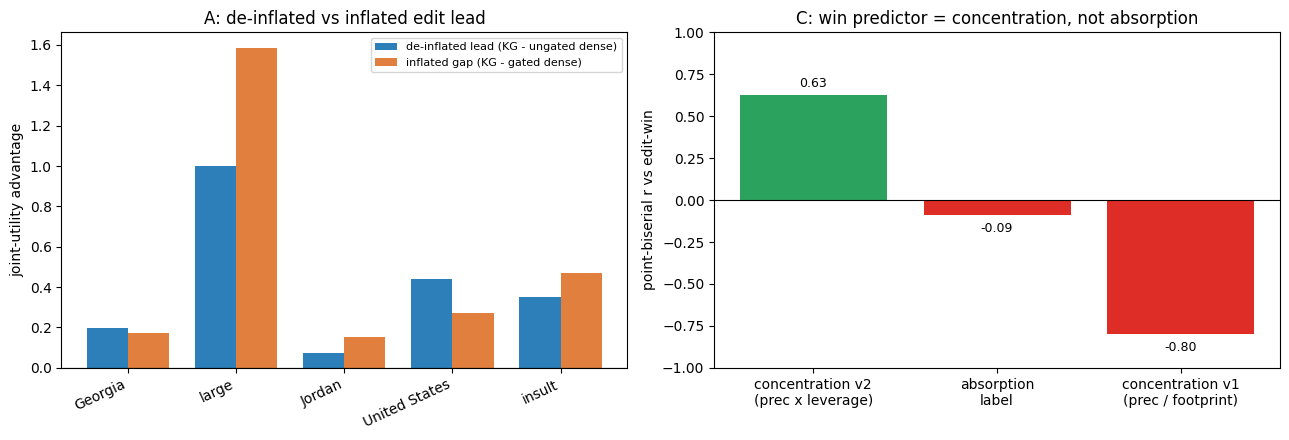

In [17]:
# ---- headline summary ----
print(f"CROSS-CHECKS: {n_pass}/{n_total} pass" + ("" if n_pass == n_total else f"  FAILED: {[r['name'] for r in xc.rows if not r['match']]}"))
print()
hl = [
    ("de-inflated lead (KG-SUB), large", clean.get("de_inflated_lead_large")),
    ("  CI", f"[{clean.get('de_inflated_lead_large_ci_lo'):.2f}, {clean.get('de_inflated_lead_large_ci_hi'):.2f}]"),
    ("inflated gap (KG-GATED), large", clean.get("inflated_gap_large")),
    ("over-erasure ratio (gated/sub)", clean.get("over_erasure_ratio_large")),
    ("gated beta (large)", clean.get("scale_gated_beta_large")),
    ("corr concentration-v2 vs win", clean.get("corr_concentration_v2_win")),
    ("corr absorption-label vs win", clean.get("corr_absorption_label_win")),
    ("corr concentration-v1(footprint) vs win", clean.get("corr_concentration_v1_win")),
    ("Georgia iter-6 adv (retracted)", clean.get("retraction_iter6_georgia_adv")),
    ("  Georgia iter-7 max forget-KG", clean.get("retraction_iter7_max_forget_kg")),
]
print(f"{'metric':<42} value")
print("-" * 60)
for name, v in hl:
    vs = f"{v:.4f}" if isinstance(v, (int, float)) else str(v)
    print(f"{name:<42} {vs}")

# ---- plots ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) per-case de-inflated lead vs inflated gap (D1 cases)
d1_rows = [r for r in a_rows if r["source"] == "D1_iter7_exp1"]
labels = [r["target_subcontext"] for r in d1_rows]
lead = [r["lead_diff_KG_vs_SUB"] for r in d1_rows]
infl = [r["inflated_diff_KG_vs_GATED"] for r in d1_rows]
x = np.arange(len(labels)); w = 0.38
ax1.bar(x - w/2, lead, w, label="de-inflated lead (KG - ungated dense)", color="#2c7fb8")
ax1.bar(x + w/2, infl, w, label="inflated gap (KG - gated dense)", color="#d95f0e", alpha=0.8)
ax1.axhline(0, color="k", lw=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=25, ha="right")
ax1.set_ylabel("joint-utility advantage"); ax1.set_title("A: de-inflated vs inflated edit lead")
ax1.legend(fontsize=8)

# (2) Group C win-predictor correlations
cnames = ["concentration v2\n(prec x leverage)", "absorption\nlabel", "concentration v1\n(prec / footprint)"]
cvals = [clean.get("corr_concentration_v2_win"), clean.get("corr_absorption_label_win"),
         clean.get("corr_concentration_v1_win")]
colors = ["#2ca25f" if v and v > 0 else "#de2d26" for v in cvals]
ax2.bar(cnames, cvals, color=colors)
ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("point-biserial r vs edit-win"); ax2.set_ylim(-1, 1)
ax2.set_title("C: win predictor = concentration, not absorption")
for i, v in enumerate(cvals):
    ax2.text(i, v + (0.05 if v >= 0 else -0.1), f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()